<a href="https://colab.research.google.com/github/ramyatangilla-png/Data-Analytics-Projects/blob/main/Diamond_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving diamonds.csv to diamonds.csv


In [3]:
df = pd.read_csv("diamonds.csv")

In [4]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
df.shape

(53940, 11)

In [6]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [8]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [10]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

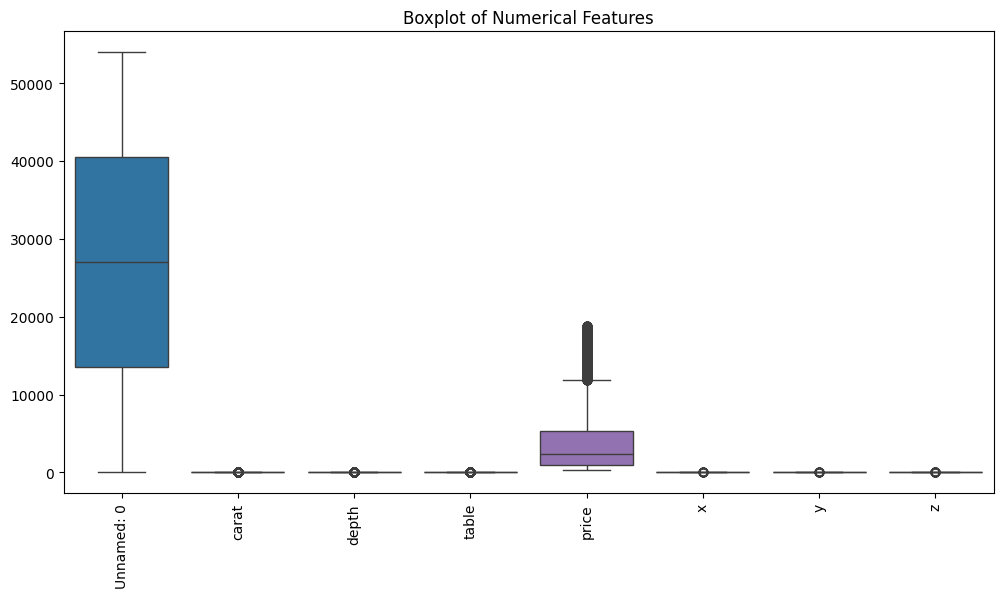

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

In [14]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Outliers removed successfully.")

Outliers removed successfully.


In [15]:
df.mean(numeric_only=True)

,0
Unnamed: 0,27276.665478
carat,0.697966
depth,61.804302
table,57.238621
price,2999.000107
x,5.521339
y,5.526371
z,3.413855


In [16]:
df.median(numeric_only=True)

,0
Unnamed: 0,29391.50
carat,0.59
depth,61.90
table,57.00
price,2002.50
x,5.39
y,5.40
z,3.33


In [17]:
df.mode().iloc[0]

,0
Unnamed: 0,1
carat,0.3
cut,Ideal
color,G
clarity,SI1
depth,62.0
table,56.0
price,605.0
x,4.37
y,4.34


In [18]:
df.var(numeric_only=True)

,0
Unnamed: 0,2.586584e+08
carat,1.310619e-01
depth,1.160664e+00
table,4.055556e+00
price,6.753005e+06
x,9.302145e-01
y,9.190052e-01
z,3.566657e-01


In [19]:
df.std(numeric_only=True)

,0
Unnamed: 0,16082.858945
carat,0.362025
depth,1.077341
table,2.013841
price,2598.654394
x,0.964476
y,0.958648
z,0.597215


In [20]:
df["cut"].value_counts()

,count
cut,
Ideal,20096
Premium,11748
Very Good,10744
Good,3677
Fair,267


In [21]:
df["color"].value_counts()

,count
color,
G,9868
E,8740
F,8289
H,6983
D,6070
I,4379
J,2203


In [22]:
df["clarity"].value_counts()

,count
clarity,
SI1,11271
VS2,10717
VS1,7253
SI2,7241
VVS2,4573
VVS1,3393
IF,1618
I1,466


In [23]:
df[["carat","price","depth","table"]].describe()

,carat,price,depth,table
count,46532.000000,46532.000000,46532.000000,46532.000000
mean,0.697966,2999.000107,61.804302,57.238621
std,0.362025,2598.654394,1.077341,2.013841
min,0.200000,326.000000,59.000000,52.000000
25%,0.370000,880.000000,61.200000,56.000000
50%,0.590000,2002.500000,61.900000,57.000000
75%,1.010000,4523.000000,62.500000,59.000000
max,2.000000,11040.000000,64.600000,63.500000


In [24]:
corr = df.corr(numeric_only=True)
corr

,Unnamed: 0,carat,depth,table,price,x,y,z
Unnamed: 0,1.000000,-0.487113,-0.045187,-0.116683,-0.461180,-0.470437,-0.471404,-0.473168
carat,-0.487113,1.000000,0.043724,0.189864,0.924790,0.986594,0.985719,0.985459
depth,-0.045187,0.043724,1.000000,-0.227730,0.014074,-0.002713,-0.004540,0.098628
table,-0.116683,0.189864,-0.227730,1.000000,0.140734,0.187542,0.182032,0.161783
price,-0.461180,0.924790,0.014074,0.140734,1.000000,0.904027,0.905075,0.900900
x,-0.470437,0.986594,-0.002713,0.187542,0.904027,1.000000,0.998496,0.993499
y,-0.471404,0.985719,-0.004540,0.182032,0.905075,0.998496,1.000000,0.993305
z,-0.473168,0.985459,0.098628,0.161783,0.900900,0.993499,0.993305,1.000000


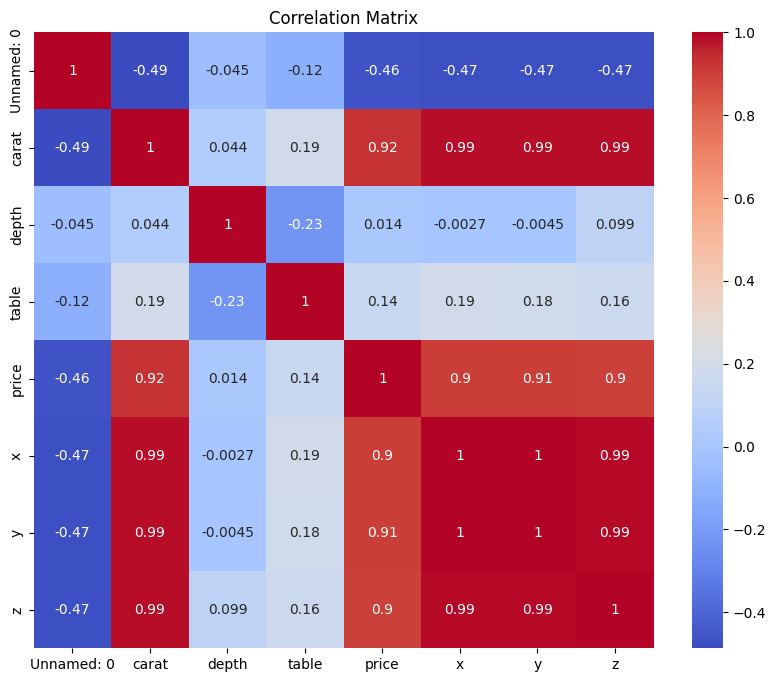

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

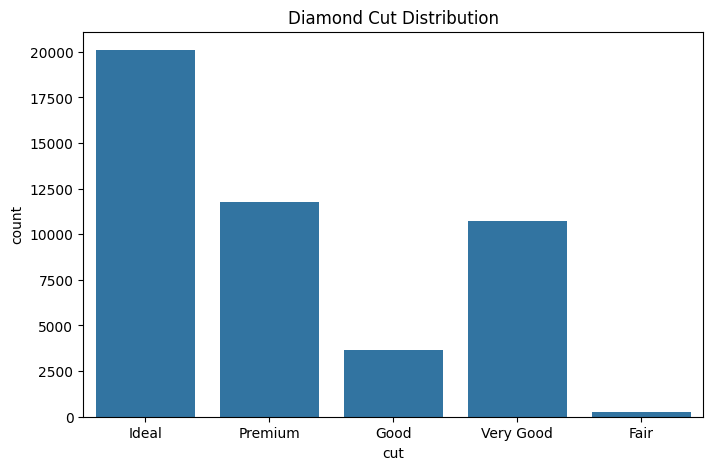

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x="cut", data=df)
plt.title("Diamond Cut Distribution")
plt.show()

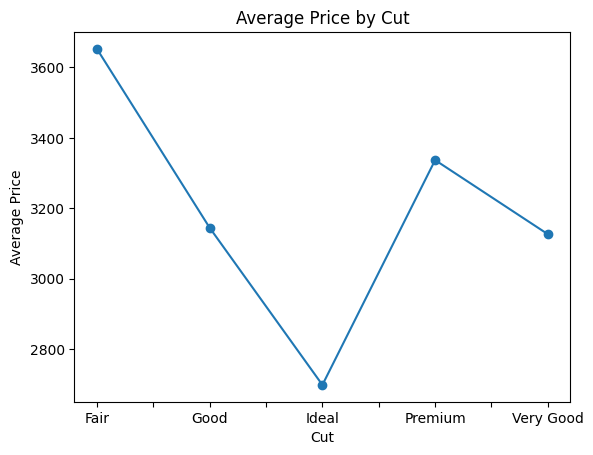

In [27]:
df.groupby("cut")["price"].mean().plot(marker="o")

plt.title("Average Price by Cut")
plt.xlabel("Cut")
plt.ylabel("Average Price")
plt.show()

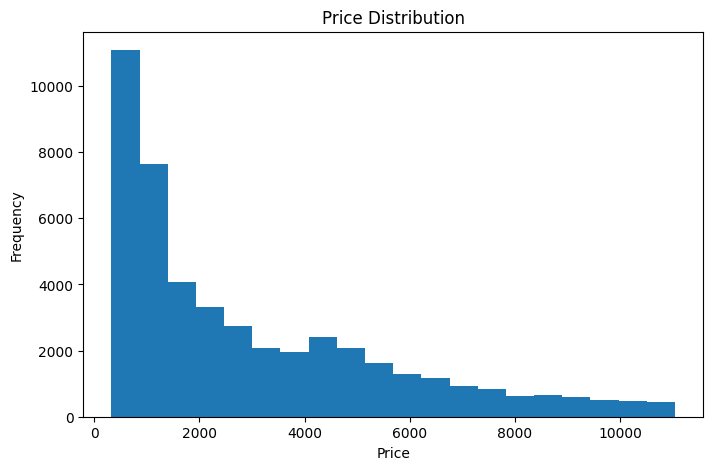

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=20)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

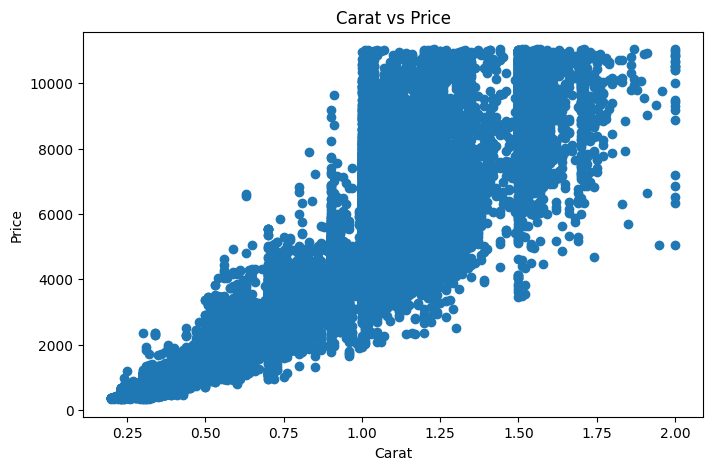

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df["carat"], df["price"])

plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Carat vs Price")
plt.show()

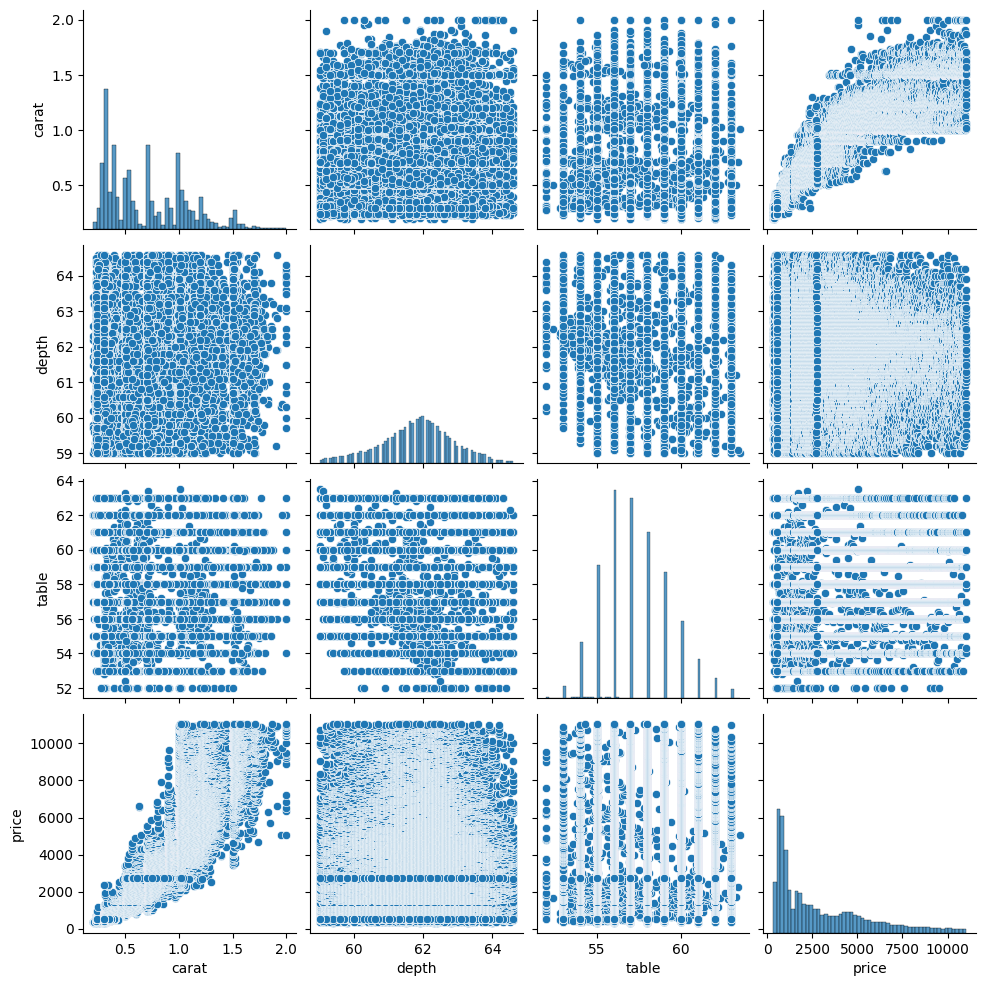

In [30]:
sns.pairplot(df[["carat","depth","table","price"]])
plt.show()

In [31]:
df.groupby("cut")["price"].mean()

,price
cut,
Fair,3652.730337
Good,3144.586620
Ideal,2698.101015
Premium,3336.859210
Very Good,3126.311337


In [32]:
df.groupby("color")["price"].mean()

,price
color,
D,2565.477100
E,2489.110755
F,2954.447943
G,3091.434536
H,3341.453673
I,3525.717287
J,3837.502043


In [33]:
df.groupby("clarity")["price"].mean()

,price
clarity,
I1,3299.206009
IF,1958.498146
SI1,3134.521249
SI2,3700.103301
VS1,3039.281814
VS2,2984.518989
VVS1,1974.043030
VVS2,2622.923026


## Objective

The objective of this project is to analyze how different features such as carat, cut, color, clarity, depth, and table influence diamond prices using Exploratory Data Analysis (EDA).

## Dataset Description

The Diamonds dataset contains information about diamonds, including their carat weight, cut, color, clarity, dimensions, depth, table, and price. It helps identify the factors that influence the price of diamonds.

## Business Insights

- Carat has the strongest positive impact on diamond price.
- Better cut quality generally increases diamond value.
- Diamonds with higher clarity tend to be more expensive.
- Better color grades often have higher prices.
- Price increases significantly with carat weight.

## EDA Summary

The Diamonds dataset was successfully cleaned and analyzed. Missing values and duplicate records were handled. Outliers were detected using boxplots and treated using the IQR method. Correlation analysis showed that carat has the strongest positive relationship with price. Visualizations helped understand the relationship between different features and diamond prices.

## Conclusion

This project successfully analyzed the Diamonds dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn. The analysis showed that carat is the most influential feature affecting diamond prices, while cut, color, and clarity also contribute significantly to pricing.